**Identifiying Exoplanets wiht ML and DL Algorithms**

In [16]:
#Import Libraries
import os
import warnings
import math
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
test= pd.read_csv('exoTest.csv')
train=pd.read_csv('exoTrain.csv')

In [18]:
train.describe()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.007273,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,0.084982,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,1.000000,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,1.000000,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,1.000000,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,1.000000,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,2.000000,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


In [19]:
train['LABEL'].value_counts()

,count
LABEL,
1,5050
2,37


Label 1 represents non exoplanets and label 2 represents exoplanets. They are turned into 0 and 1 to be able to work easier in the mdoel trainings. There are 3197 flux entries.

In [20]:
categ = {2: 1,1: 0}
train.LABEL = [categ[item] for item in train.LABEL]
test.LABEL = [categ[item] for item in test.LABEL]

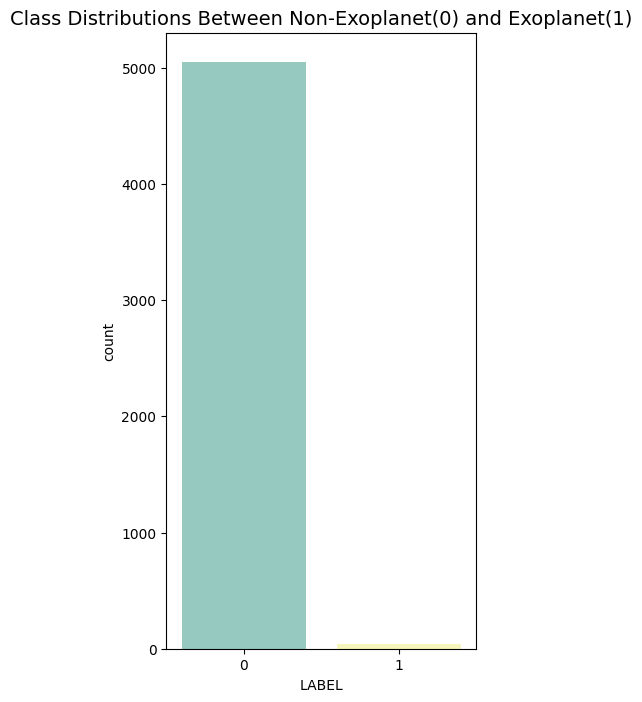

In [21]:
plt.figure(figsize=(4,8))
sns.countplot(x='LABEL', data=train, palette ="Set3" )
plt.title('Class Distributions Between Non-Exoplanet(0) and Exoplanet(1)', fontsize=14)
plt.show()

In [22]:
train.isna().values.sum()

0

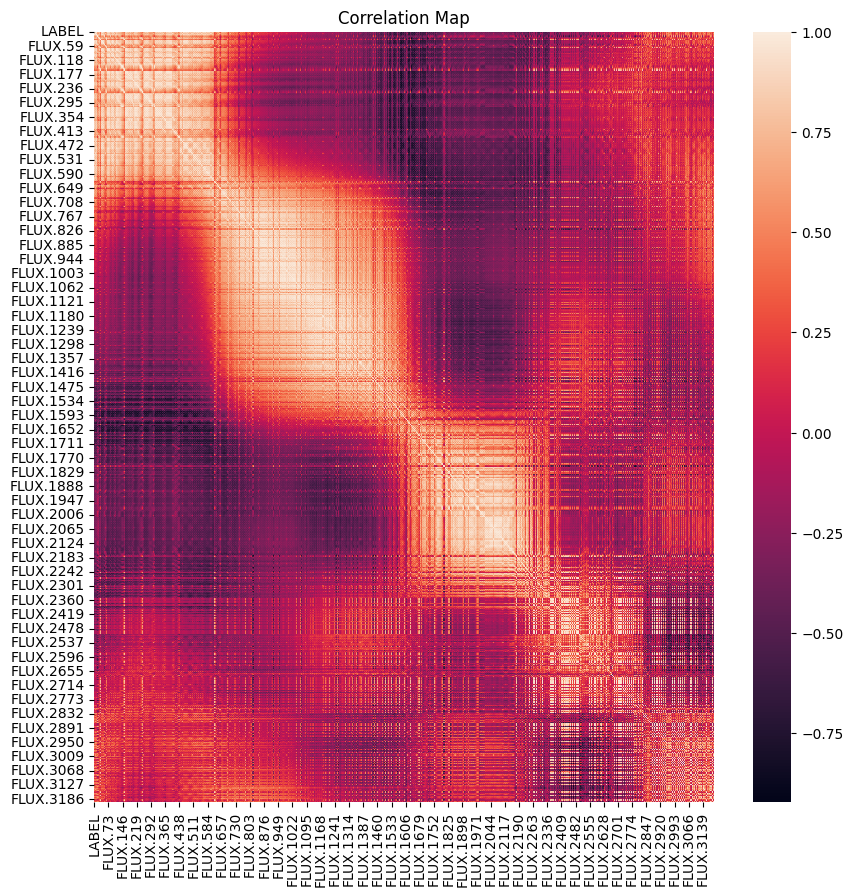

In [23]:
plt.figure(figsize=(10,10))
sns.heatmap(train.corr())
plt.title('Correlation Map')
plt.show()

Since fluxes are independent from each other, the correlation matrix does not helpful. To be able to understand flux variables better, we can draw a flux graphs.

In [24]:
train_exop=train[train['LABEL']==1]
train_nonexop=train[train['LABEL']==0]
train_t_n=train_nonexop.iloc[:,1:].T
train_t_y=train_exop.iloc[:,1:].T
train_exop.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,1,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,1,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,1,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,1,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,1,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [25]:
train_nonexop.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
37,0,-141.22,-81.79,-52.28,-32.45,-1.55,-35.61,-23.28,19.45,53.11,...,-50.79,-22.34,-36.23,27.44,13.52,38.66,-17.53,31.49,31.38,50.03
38,0,-35.62,-28.55,-27.29,-28.94,-15.13,-51.06,2.67,-5.21,9.67,...,-43.98,-38.22,-46.23,-54.40,-23.51,-26.96,-3.95,-0.34,10.52,-7.69
39,0,142.40,137.03,93.65,105.64,98.22,99.06,86.40,60.78,45.18,...,-0.99,-3.03,-30.27,-24.22,-35.10,-39.64,23.78,23.40,-0.50,0.97
40,0,-167.02,-137.65,-150.05,-136.85,-98.73,-103.14,-107.70,-123.19,-125.65,...,-97.43,-79.79,-80.62,-78.22,-105.06,-69.67,-90.45,-73.67,-66.71,-66.07
41,0,207.74,223.60,246.15,224.06,210.77,189.56,172.68,170.31,148.79,...,-53.06,-136.92,-174.97,-180.46,-164.01,-126.58,84.05,63.81,108.36,78.10


In [26]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
fig = make_subplots(rows=2, cols=2,subplot_titles=("Flux variation of star 37", "Flux variation of star 38",
                                                   "Flux variation of star 39", "Flux variation of star 40"))
fig.add_trace(
    go.Scatter(y=train_t_n[37], x=train_t_n.index),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(y=train_t_n[38], x=train_t_n.index),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(y=train_t_n[39], x=train_t_n.index),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(y=train_t_n[40], x=train_t_n.index),
    row=2, col=2
)
fig.update_layout(height=600, width=800, title_text="Non Exoplanets Star examples",showlegend=False)
fig.show()

In [27]:

fig = make_subplots(rows=2, cols=2,subplot_titles=("Flux variation of star 0", "Flux variation of star 1",
                                                   "Flux variation of star 35", "Flux variation of star 36"))
fig.add_trace(
    go.Scatter(y=train_t_y[0], x=train_t_y.index),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(y=train_t_y[1], x=train_t_y.index),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(y=train_t_y[35], x=train_t_y.index),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(y=train_t_y[36], x=train_t_y.index),
    row=2, col=2
)
fig.update_layout(height=600, width=800, title_text="Exoplanets Stars examples",showlegend=False)
fig.show()

In [28]:
#Normalising the Flux
from sklearn.preprocessing import StandardScaler
trainx=train.iloc[:,1:]
testx=test.iloc[:,1:]
scaler=StandardScaler()
train_scaled=scaler.fit_transform(trainx)
test_scaled=scaler.fit_transform(testx)

In [29]:
trainy=train[['LABEL']]
testy=test[['LABEL']]

In [30]:
#Dimentiolly reducing the data
from sklearn.decomposition import PCA
pca = PCA(n_components=6)
pca.fit(train_scaled)
PCA(n_components=6)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)
trns_x=pca.transform(train_scaled)
trns_y=pca.transform(test_scaled)


[0.27373539 0.22536219 0.14929127 0.09802696 0.05819974 0.04072856]
[2109.92811427 1914.4441909  1558.18634093 1262.62663108  972.8876534
  813.86372792]


In [31]:
trns_y.shape

(570, 6)

In [32]:
trainy.loc[trainy['LABEL'] == 0, 'new1'] = 0
trainy.loc[trainy['LABEL'] > 0, 'new1'] = 1
testy.loc[testy['LABEL'] > 0, 'new1'] = 1
testy.loc[testy['LABEL'] == 0, 'new1'] = 0

Because data is imbalance, before training the data SMOTE used for balancing the data

In [33]:

from imblearn.over_sampling import SMOTE
over = SMOTE(random_state=0)
ov_train_x,ov_train_y=over.fit_resample(train_scaled, trainy['new1'])
ov_train_y=ov_train_y.astype('int')
ov_train_y.value_counts()

,count
new1,
1,5050
0,5050


<Axes: >

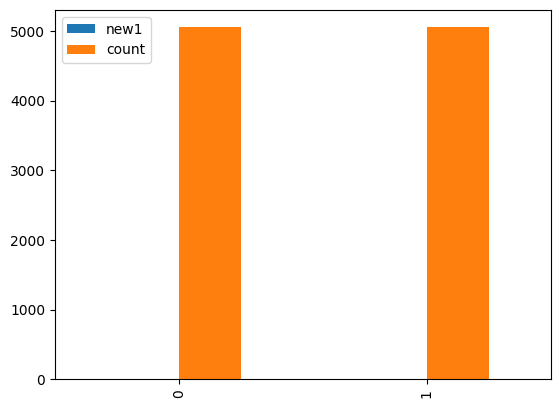

In [34]:
ov_train_y.value_counts().reset_index().plot(kind='bar')

In [35]:
#Libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import recall_score, precision_score, classification_report,accuracy_score,confusion_matrix, roc_curve, auc, roc_curve,accuracy_score
from sklearn.preprocessing import StandardScaler, normalize
from scipy import ndimage
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [36]:

x_train, x_test, y_train, y_test = train_test_split(ov_train_x, ov_train_y, test_size=0.33, random_state=42)

Validation accuracy of KNN is 0.9801980198019802

Classification report :
               precision    recall  f1-score   support

           0       1.00      0.96      0.98      1700
           1       0.96      1.00      0.98      1633

    accuracy                           0.98      3333
   macro avg       0.98      0.98      0.98      3333
weighted avg       0.98      0.98      0.98      3333



Text(0.5, 1.0, 'ROC - CURVE & AREA UNDER CURVE')

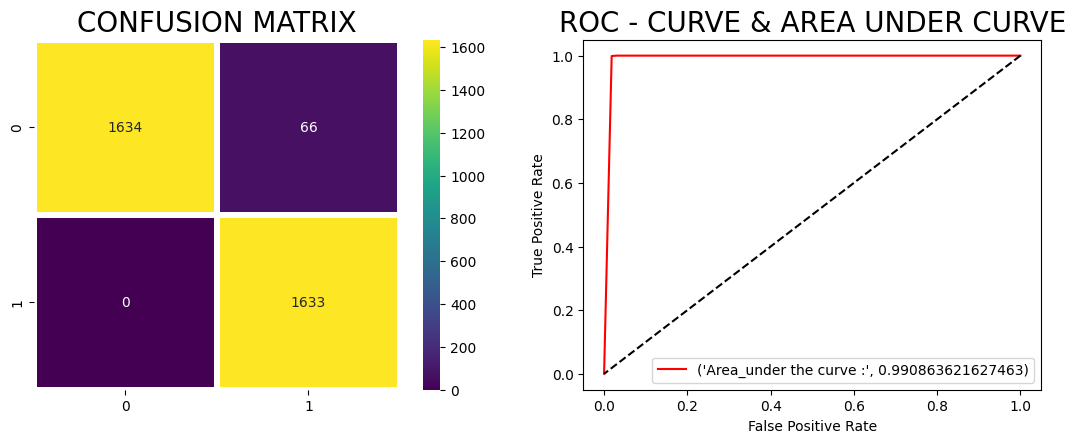

In [37]:
#K-NN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()

knn_model.fit(x_train,y_train)
prediction=knn_model.predict(x_test)
print('Validation accuracy of KNN is', accuracy_score(prediction,y_test))
print ("\nClassification report :\n",(classification_report(y_test,prediction)))

#Confusion matrix
plt.figure(figsize=(13,10))
plt.subplot(221)
sns.heatmap(confusion_matrix(y_test,prediction),annot=True,cmap="viridis",fmt = "d",linewidths=3)
plt.title("CONFUSION MATRIX",fontsize=20)

#ROC curve and Area under the curve plotting
predicting_probabilites = knn_model.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,predicting_probabilites)
plt.subplot(222)
plt.plot(fpr,tpr,label = ("Area_under the curve :",auc(fpr,tpr)),color = "r")
plt.plot([1,0],[1,0],linestyle = "dashed",color ="k")
plt.legend(loc = "best")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC - CURVE & AREA UNDER CURVE",fontsize=20)

Validation accuracy of Decision Tree is 0.9387938793879388

Classification report :
               precision    recall  f1-score   support

           0       0.98      0.90      0.94      1700
           1       0.90      0.98      0.94      1633

    accuracy                           0.94      3333
   macro avg       0.94      0.94      0.94      3333
weighted avg       0.94      0.94      0.94      3333



Text(0.5, 1.0, 'ROC - CURVE & AREA UNDER CURVE')

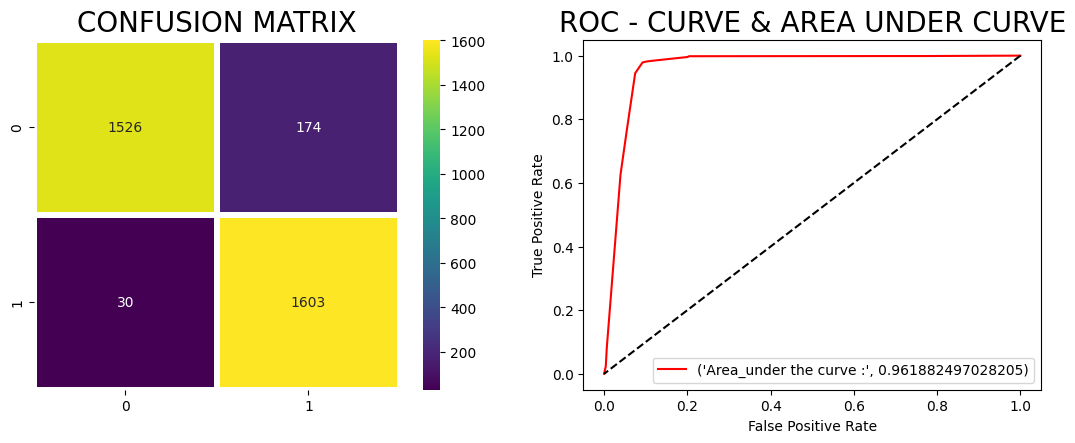

In [38]:
from sklearn.tree import DecisionTreeClassifier
ds_model = DecisionTreeClassifier(max_depth=5, random_state=13)

ds_model.fit(x_train,y_train)

prediction=ds_model.predict(x_test)

print('Validation accuracy of Decision Tree is', accuracy_score(prediction,y_test))
print ("\nClassification report :\n",(classification_report(y_test,prediction)))

#Confusion matrix
plt.figure(figsize=(13,10))
plt.subplot(221)
sns.heatmap(confusion_matrix(y_test,prediction),annot=True,cmap="viridis",fmt = "d",linewidths=3)
plt.title("CONFUSION MATRIX",fontsize=20)
#ROC curve and Area under the curve plotting
predicting_probabilites = ds_model.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,predicting_probabilites)
plt.subplot(222)
plt.plot(fpr,tpr,label = ("Area_under the curve :",auc(fpr,tpr)),color = "r")
plt.plot([1,0],[1,0],linestyle = "dashed",color ="k")
plt.legend(loc = "best")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC - CURVE & AREA UNDER CURVE",fontsize=20)

Validation accuracy of Logistic Regression is 0.6261626162616262

Classification report :
               precision    recall  f1-score   support

           0       0.58      0.98      0.73      1700
           1       0.93      0.26      0.40      1633

    accuracy                           0.63      3333
   macro avg       0.75      0.62      0.56      3333
weighted avg       0.75      0.63      0.57      3333



Text(0.5, 1.0, 'ROC - CURVE & AREA UNDER CURVE')

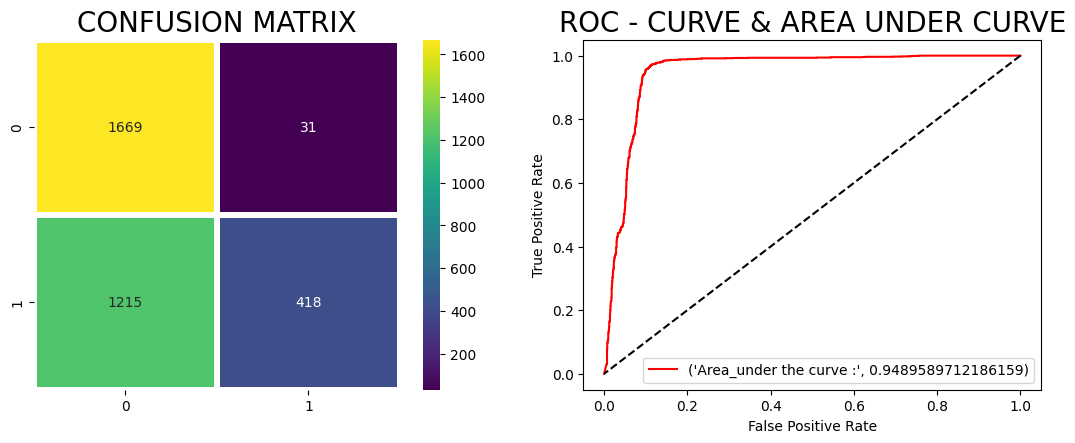

In [39]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(class_weight={0:100, 1:1})

lr_model.fit(x_train,y_train)

prediction=lr_model.predict(x_test)

print('Validation accuracy of Logistic Regression is', accuracy_score(prediction,y_test))
print ("\nClassification report :\n",(classification_report(y_test,prediction)))

#Confusion matrix
plt.figure(figsize=(13,10))
plt.subplot(221)
sns.heatmap(confusion_matrix(y_test,prediction),annot=True,cmap="viridis",fmt = "d",linewidths=3)
plt.title("CONFUSION MATRIX",fontsize=20)
#ROC curve and Area under the curve plotting
predicting_probabilites = lr_model.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,predicting_probabilites)
plt.subplot(222)
plt.plot(fpr,tpr,label = ("Area_under the curve :",auc(fpr,tpr)),color = "r")
plt.plot([1,0],[1,0],linestyle = "dashed",color ="k")
plt.legend(loc = "best")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC - CURVE & AREA UNDER CURVE",fontsize=20)


Validation accuracy of AdaBoost is 0.987998799879988

Classification report :
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1700
           1       0.98      1.00      0.99      1633

    accuracy                           0.99      3333
   macro avg       0.99      0.99      0.99      3333
weighted avg       0.99      0.99      0.99      3333



Text(0.5, 1.0, 'ROC - CURVE & AREA UNDER CURVE')

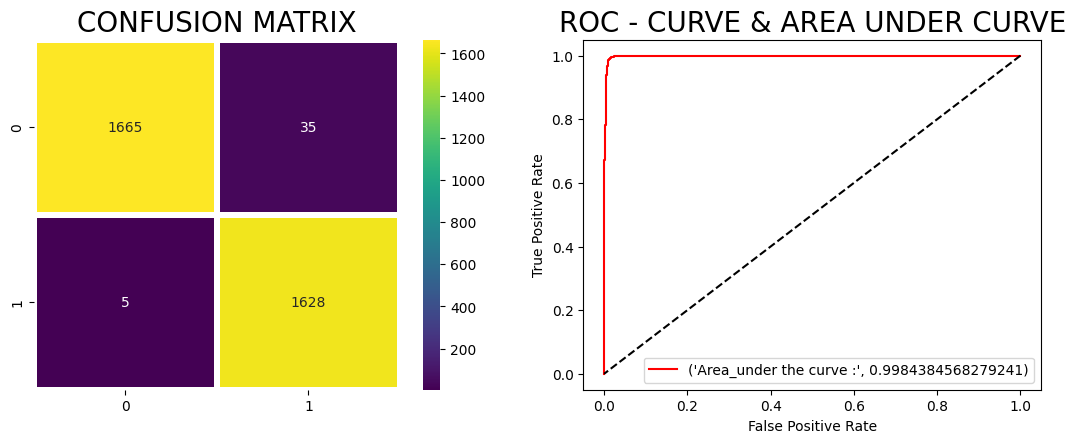

In [53]:
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier()
ada_model.fit(x_train,y_train)

prediction=ada_model.predict(x_test)

print('Validation accuracy of AdaBoost is', accuracy_score(prediction,y_test))
print ("\nClassification report :\n",(classification_report(y_test,prediction)))

#Confusion matrix
plt.figure(figsize=(13,10))
plt.subplot(221)
sns.heatmap(confusion_matrix(y_test,prediction),annot=True,cmap="viridis",fmt = "d",linewidths=3)
plt.title("CONFUSION MATRIX",fontsize=20)
#ROC curve and Area under the curve plotting
predicting_probabilites = ada_model.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,predicting_probabilites)
plt.subplot(222)
plt.plot(fpr,tpr,label = ("Area_under the curve :",auc(fpr,tpr)),color = "r")
plt.plot([1,0],[1,0],linestyle = "dashed",color ="k")
plt.legend(loc = "best")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC - CURVE & AREA UNDER CURVE",fontsize=20)

Validation accuracy of XGBoost is 0.987998799879988

Classification report :
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1700
           1       0.98      1.00      0.99      1633

    accuracy                           0.99      3333
   macro avg       0.99      0.99      0.99      3333
weighted avg       0.99      0.99      0.99      3333



Text(0.5, 1.0, 'ROC - CURVE & AREA UNDER CURVE')

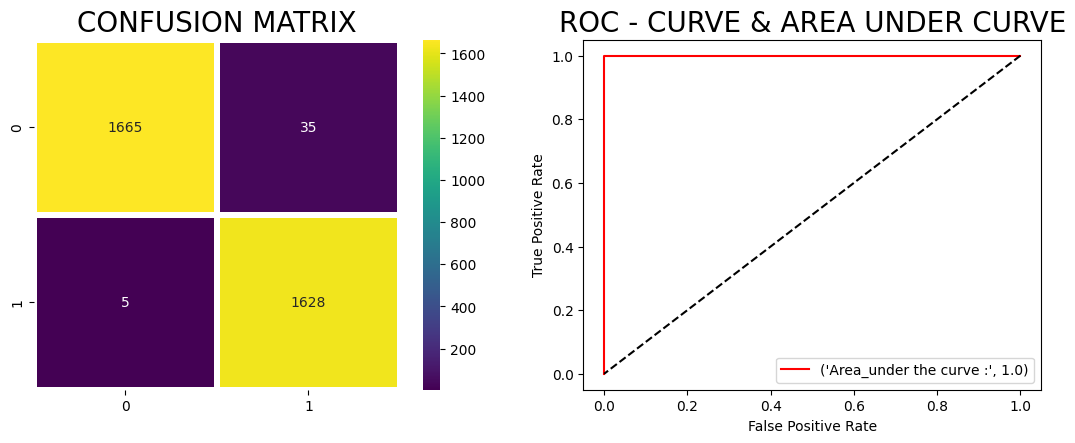

In [54]:
from xgboost import XGBClassifier
xgboost_model = XGBClassifier()
xgboost_model.fit(x_train,y_train)

prediction=ada_model.predict(x_test)

print('Validation accuracy of XGBoost is', accuracy_score(prediction,y_test))
print ("\nClassification report :\n",(classification_report(y_test,prediction)))

#Confusion matrix
plt.figure(figsize=(13,10))
plt.subplot(221)
sns.heatmap(confusion_matrix(y_test,prediction),annot=True,cmap="viridis",fmt = "d",linewidths=3)
plt.title("CONFUSION MATRIX",fontsize=20)
#ROC curve and Area under the curve plotting
predicting_probabilites = xgboost_model.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,predicting_probabilites)
plt.subplot(222)
plt.plot(fpr,tpr,label = ("Area_under the curve :",auc(fpr,tpr)),color = "r")
plt.plot([1,0],[1,0],linestyle = "dashed",color ="k")
plt.legend(loc = "best")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC - CURVE & AREA UNDER CURVE",fontsize=20)

**1D CNN**

In [42]:
from imblearn.over_sampling import SMOTE
over = SMOTE(random_state=0)
ov_train_x,ov_train_y=over.fit_resample(trns_x, trainy['new1'])
ov_train_y=ov_train_y.astype('int')
ov_train_y.value_counts()


,count
new1,
1,5050
0,5050


In [43]:
ov_train_y=np.array(ov_train_y)
ov_train_y.dtype

tr_x,v_x,tr_y,V_y= train_test_split(ov_train_x, ov_train_y, test_size=0.2)



Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5232 - loss: 4.5271 - val_accuracy: 0.4871 - val_loss: 4.4169 - learning_rate: 3.1623e-04
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5414 - loss: 4.4070 - val_accuracy: 0.6356 - val_loss: 4.3937 - learning_rate: 3.1623e-04
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6271 - loss: 4.3885 - val_accuracy: 0.6317 - val_loss: 4.3784 - learning_rate: 3.1623e-04
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6115 - loss: 4.3758 - val_accuracy: 0.6609 - val_loss: 4.3650 - learning_rate: 3.1623e-04
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6388 - loss: 4.3637 - val_accuracy: 0.6327 - val_loss: 4.3507 - learning_rate: 3.1623e-04
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6174 - loss: 4.3520 - val_accuracy: 0.6421 - val_loss: 4.3381 - learning_rate: 3.1623e-04
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 

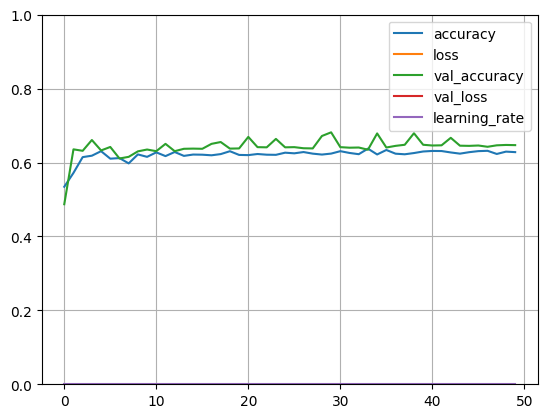

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[[ 24 541]
 [  0   5]]
              precision    recall  f1-score   support

         0.0       1.00      0.04      0.08       565
         1.0       0.01      1.00      0.02         5

    accuracy                           0.05       570
   macro avg       0.50      0.52      0.05       570
weighted avg       0.99      0.05      0.08       570



In [44]:
model=keras.models.Sequential([
    keras.layers.Dense(300,activation="selu",input_shape=(tr_x.shape[1],)),
    keras.layers.Dense(200,activation="selu",kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(100,activation="selu",kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(2,activation="softmax")
])
epochs=50
optimizers=keras.optimizers.SGD(clipvalue=1.0)
def exp_decay(lr0,s):
    def exp_decay_fn(epcohs):
        return lr0*0.1**(epochs/s)
    return exp_decay_fn
exp_decay_fn=exp_decay(lr0=0.1,s=20)
lr_sch=keras.callbacks.LearningRateScheduler(exp_decay_fn)
lr_sch2=keras.callbacks.ReduceLROnPlateau(factor=0.5,patience=5)
model.compile(loss="sparse_categorical_crossentropy",optimizer=optimizers,metrics=["accuracy"])
history=model.fit(tr_x,tr_y,epochs=50,callbacks=[lr_sch],validation_data=(v_x,V_y))
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot()
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()
predict = np.argmax(model.predict(trns_y),axis=1)
print(confusion_matrix(testy['new1'], predict))
print(classification_report(testy['new1'], predict))

Using Adam Optimizer

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5531 - loss: 0.6770 - val_accuracy: 0.6569 - val_loss: 0.6475 - learning_rate: 0.0010
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5710 - loss: 0.6527 - val_accuracy: 0.5005 - val_loss: 0.6507 - learning_rate: 0.0010
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6114 - loss: 0.6418 - val_accuracy: 0.7401 - val_loss: 0.6127 - learning_rate: 0.0010
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6557 - loss: 0.6118 - val_accuracy: 0.5906 - val_loss: 0.6076 - learning_rate: 0.0010
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6888 - loss: 0.5972 - val_accuracy: 0.7411 - val_loss: 0.5927 - learning_rate: 0.0010
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6938 - loss: 0.5823 - val_accuracy: 0.7713 - val_loss: 0.6025 - learning_rate: 0.0010
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7138 - loss: 0.7475 - 

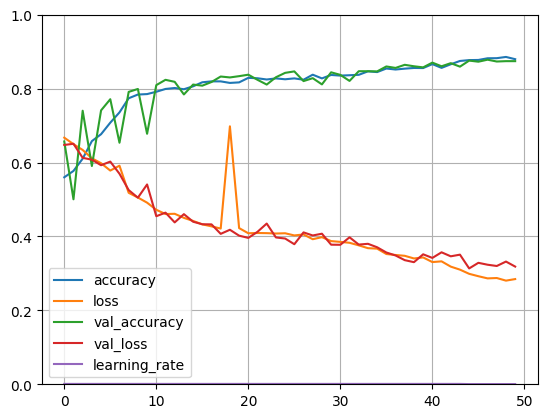

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[557   8]
 [  5   0]]
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       565
         1.0       0.00      0.00      0.00         5

    accuracy                           0.98       570
   macro avg       0.50      0.49      0.49       570
weighted avg       0.98      0.98      0.98       570



In [45]:

model = keras.models.Sequential([
    keras.layers.Dense(300, activation="swish", input_shape=(tr_x.shape[1],)),
    keras.layers.Dense(200, activation="swish", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="swish", kernel_initializer="he_normal"),
    keras.layers.Dense(2, activation="softmax")
])

optimizers = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    name="Adam"
)

lr_sch2 = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizers, metrics=["accuracy"])

# Make sure tr_x and v_x have the correct shape
# For instance, remove reshaping if it's not necessary
tr_x = tr_x.reshape((tr_x.shape[0], tr_x.shape[1]))
v_x = v_x.reshape((v_x.shape[0], v_x.shape[1]))

history = model.fit(tr_x, tr_y, epochs=50, validation_data=(v_x, V_y), callbacks=[lr_sch2])

import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot()
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

# Ensure trns_y is correctly shaped for prediction
trns_y = trns_y.reshape((trns_y.shape[0], trns_y.shape[1]))

predict = np.argmax(model.predict(trns_y), axis=1)
print(confusion_matrix(testy['new1'], predict))
print(classification_report(testy['new1'], predict))


Adding convolutional layers

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5529 - loss: 0.9895 - val_accuracy: 0.6861 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6854 - loss: 0.5896 - val_accuracy: 0.7282 - val_loss: 0.5430 - learning_rate: 0.0010
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7024 - loss: 0.5868 - val_accuracy: 0.7762 - val_loss: 0.4939 - learning_rate: 0.0010
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7537 - loss: 0.5177 - val_accuracy: 0.7936 - val_loss: 0.4942 - learning_rate: 0.0010
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7792 - loss: 0.4822 - val_accuracy: 0.8045 - val_loss: 0.4519 - learning_rate: 0.0010
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7848 - loss: 0.4659 - val_accuracy: 0.8149 - val_loss: 0.4316 - learning_rate: 0.0010
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8116 - loss: 0.4300 -

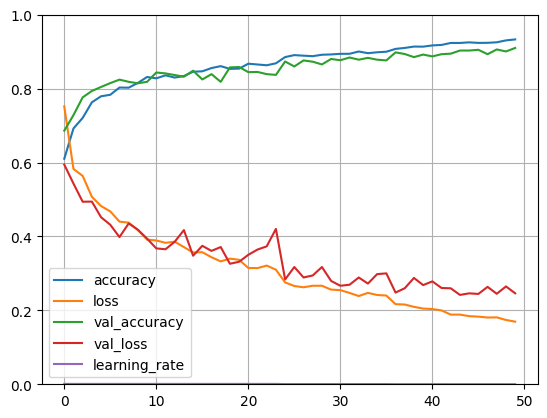

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[[558   7]
 [  5   0]]
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       565
         1.0       0.00      0.00      0.00         5

    accuracy                           0.98       570
   macro avg       0.50      0.49      0.49       570
weighted avg       0.98      0.98      0.98       570



In [46]:
model = keras.models.Sequential([
    keras.layers.Conv1D(filters=64, kernel_size=2, activation='relu', padding='same', input_shape=(tr_x.shape[1], 1)),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(filters=128, kernel_size=2, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="swish"),
    keras.layers.Dense(200, activation="swish", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="swish", kernel_initializer="he_normal"),
    keras.layers.Dense(2, activation="softmax")
])



optimizers=tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    name="Adam"

)
tr_x = tr_x.reshape((tr_x.shape[0], tr_x.shape[1], 1))
v_x = v_x.reshape((v_x.shape[0], v_x.shape[1], 1))
lr_sch2=keras.callbacks.ReduceLROnPlateau(factor=0.5,patience=5)
model.compile(loss="sparse_categorical_crossentropy",optimizer=optimizers,metrics=["accuracy"])
history=model.fit(tr_x,tr_y,epochs=50,validation_data=(v_x,V_y),callbacks=[lr_sch2])
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot()
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()
predict = np.argmax(model.predict(trns_y),axis=1)
print(confusion_matrix(testy['new1'], predict))
print(classification_report(testy['new1'], predict))

In [47]:

misclassified_indices = np.where(testy['new1'] != predict)[0]
import matplotlib.pyplot as plt

# Loop over the misclassified instances
for i in misclassified_indices:
    print(f"Index: {i}")
    print(f"True label: {testy['new1'].iloc[i]}")
    print(f"Predicted label: {predict[i]}")

num_misclassified = len(misclassified_indices)

Index: 0
True label: 1.0
Predicted label: 0
Index: 1
True label: 1.0
Predicted label: 0
Index: 2
True label: 1.0
Predicted label: 0
Index: 3
True label: 1.0
Predicted label: 0
Index: 4
True label: 1.0
Predicted label: 0
Index: 37
True label: 0.0
Predicted label: 1
Index: 64
True label: 0.0
Predicted label: 1
Index: 84
True label: 0.0
Predicted label: 1
Index: 262
True label: 0.0
Predicted label: 1
Index: 400
True label: 0.0
Predicted label: 1
Index: 421
True label: 0.0
Predicted label: 1
Index: 569
True label: 0.0
Predicted label: 1


In [48]:
num_misclassified = len(misclassified_indices)
num_misclassified

12

**LSTM**

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.5199 - loss: 0.6893 - val_accuracy: 0.5931 - val_loss: 0.6669 - learning_rate: 0.0010
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5507 - loss: 0.6711 - val_accuracy: 0.4668 - val_loss: 0.6668 - learning_rate: 0.0010
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5578 - loss: 0.6593 - val_accuracy: 0.4827 - val_loss: 0.6553 - learning_rate: 0.0010
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5728 - loss: 0.6570 - val_accuracy: 0.6634 - val_loss: 0.6398 - learning_rate: 0.0010
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5971 - loss: 0.6562 - val_accuracy: 0.5099 - val_loss: 0.6539 - learning_rate: 0.0010
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5869 - loss: 0.6532 - val_accuracy: 0.7020 - val_loss: 0.6365 - learning_rate: 0.0010
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6053 - loss: 0

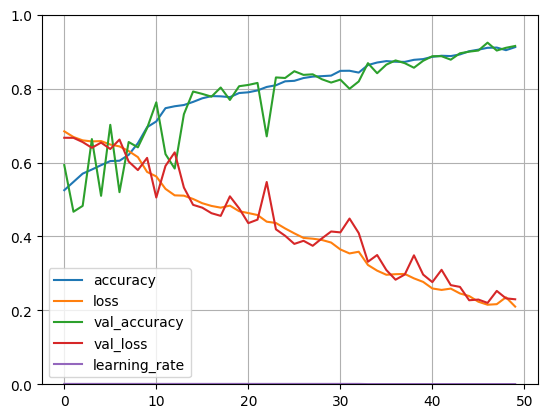

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
[[928 110]
 [ 61 921]]
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      1038
           1       0.89      0.94      0.92       982

    accuracy                           0.92      2020
   macro avg       0.92      0.92      0.92      2020
weighted avg       0.92      0.92      0.92      2020



In [49]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Define the LSTM model
model = keras.models.Sequential([
    keras.layers.LSTM(64, return_sequences=True, input_shape=(tr_x.shape[1], 1)),
    keras.layers.LSTM(128, return_sequences=False),
    keras.layers.Dense(300, activation="swish"),
    keras.layers.Dense(200, activation="swish", kernel_initializer="he_normal"),
    keras.layers.Dense(100, activation="swish", kernel_initializer="he_normal"),
    keras.layers.Dense(2, activation="softmax")
])

# Define the optimizer
optimizers = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    name="Adam"
)

# Reshape the data
tr_x = tr_x.reshape((tr_x.shape[0], tr_x.shape[1], 1))
v_x = v_x.reshape((v_x.shape[0], v_x.shape[1], 1))

# Define the learning rate scheduler
lr_sch2 = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)

# Compile the model
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizers, metrics=["accuracy"])

# Train the model
history = model.fit(tr_x, tr_y, epochs=50, validation_data=(v_x, V_y), callbacks=[lr_sch2])

# Plot training history
pd.DataFrame(history.history).plot()
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

# Make predictions
predict = np.argmax(model.predict(v_x), axis=1)

# Print evaluation metrics
print(confusion_matrix(V_y, predict))
print(classification_report(V_y, predict))


In [52]:
import tensorflow as tf
import sklearn

# Check Python package versions
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

# Check if GPU is available and print details
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
!nvidia-smi

# System and hardware details
!cat /proc/cpuinfo | grep 'model name' | uniq
!cat /proc/meminfo | grep 'MemTotal'

Pandas version: 2.1.4
Numpy version: 1.26.4
Seaborn version: 0.13.1
TensorFlow version: 2.17.0
Scikit-Learn version: 1.3.2
Num GPUs Available:  0
/bin/bash: line 1: nvidia-smi: command not found
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
MemTotal:       13290452 kB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')